In [1]:
import os
from params.paths import ROOT_DIR, CHROMEDRIVER_PATH
from file_handling.file_read_writer import read_json, write_json, create_dir, write_file
from data_process.string_processor import StringProcessor
from collections import Counter, OrderedDict
import pandas as pd
import numpy as np
import re

In [2]:
# params and paths
DATA_DIR = os.path.join(ROOT_DIR, 'data_prepping', 'data')
SPEECHES_DIR = os.path.join(DATA_DIR, 'data_repr')

# Testing out mecab and unidic

In [3]:
sp = StringProcessor()
split_string_words, extra = sp.divide_string("生国務大臣　一九五一年、朝鮮事変勃発、そのときにこの日米安保条約というのは結ばれたのが最初だと思いますが、そのときに、サンフランシスコの講和条約、まあ、あのころみんながちゃがちゃと始まったんですけれども。\r\n　記憶にあるのは、あのときは、単独講和か全面講和かという言葉がえらく新聞に躍っていましたけれども、日本の加盟に賛成したのは四十三カ国が単独で、反対したのはソ連、ポーランド、ハンガリーだったかな、その三カ国は反対ということで、これは、四十三対三だったら、単独講和じゃなくて多数講和か全面講和かの違いなんじゃないのと、子供心にそう思った記憶がありますけれども。\r\n　あの時代から七十年近くがたちまして、今は、米ソ冷戦というのは、三十年前、八九年に終わっております。ベルリンの壁崩壊とともに終わっておりますので。\r\n　今は、新たに、米中みたいな形になってきて、間違いなく、日本の周辺水域や何かにおいても、北の守りよりは、むしろ、我々の方の南のところで、南シナ海の話とか東シナ海の話とか北朝鮮の話になってきて、状況は随分変わってきたと思いますが、この日米安全保障条約というものが日本の防衛、安保、外交等々の中において非常に大きな役割を果たしておりますので、今後ともこの日米安全保障条約というものが日本の防衛、外交上極めて重要なものであり続けるであろうというのは、この間の六十周年に行って、改めてそう感じたところです")
print(split_string_words)
print(extra)
to_df = pd.DataFrame({"word": split_string_words, "extra": extra})
to_df.to_csv("test.csv", index=False)
print(Counter(split_string_words)+Counter(split_string_words))

['生', '国務', '大臣', '\u3000', '一', '九', '五', '一', '年', '、', '朝鮮', '事変', '勃発', '、', 'その', 'とき', 'に', 'この', '日米', '安保', '条約', 'と', 'いう', 'の', 'は', '結ば', 'れ', 'た', 'の', 'が', '最初', 'だ', 'と', '思い', 'ます', 'が', '、', 'その', 'とき', 'に', '、', 'サンフランシスコ', 'の', '講和', '条約', '、', 'まあ', '、', 'あの', 'ころ', 'みんな', 'がちゃがちゃ', 'と', '始まっ', 'た', 'ん', 'です', 'けれど', 'も', '。', '\r', '\u3000', '記憶', 'に', 'ある', 'の', 'は', '、', 'あの', 'とき', 'は', '、', '単独', '講和', 'か', '全面', '講和', 'か', 'と', 'いう', '言葉', 'が', 'えらく', '新聞', 'に', '躍っ', 'て', 'い', 'まし', 'た', 'けれど', 'も', '、', '日本', 'の', '加盟', 'に', '賛成', 'し', 'た', 'の', 'は', '四十', '三', 'カ国', 'が', '単独', 'で', '、', '反対', 'し', 'た', 'の', 'は', 'ソ連', '、', 'ポーランド', '、', 'ハンガリー', 'だっ', 'た', 'か', 'な', '、', 'その', '三', 'カ国', 'は', '反対', 'と', 'いう', 'こと', 'で', '、', 'これ', 'は', '、', '四十', '三', '対', '三', 'だっ', 'たら', '、', '単独', '講和', 'じゃ', 'なく', 'て', '多数', '講和', 'か', '全面', '講和', 'か', 'の', '違い', 'な', 'ん', 'じゃ', 'ない', 'の', 'と', '、', '子供', '心', 'に', 'そう', '思っ', 'た', '記憶', 'が', 'あり', 'ます', 'けれど', 'も', '。',

## Seeing whether there is value to be gained from counting the words in the speeches

In [4]:
defence_speech_dir = os.path.join(SPEECHES_DIR, '安全保障・安保・防衛')
asuo_file = os.path.join(defence_speech_dir, 'asuo_tarou.json') 
asuo_json = read_json(asuo_file)
speeches = asuo_json['speechRecord']
asuo_counting = Counter()
exclusions = ['助動詞', '補助記号','助詞','空白','連体詞','動詞']
for speech in speeches:
    speech_string = speech['speech']
    split_string, extra = sp.divide_string(speech_string, exclusions)
    
    # print(extra)
    counted = Counter(split_string)
    asuo_counting += counted

# print(asuo_counting)
# print(sorted(asuo_counting.items(), key=lambda x: x[1], reverse=True)[:10])
asuo_df = pd.DataFrame(sorted(asuo_counting.items(), key=lambda x: x[1], reverse=True), columns=['word', 'count'])
asuo_df.to_csv(os.path.join(defence_speech_dir, 'asuo_counting.csv'), index=False)

# Using bert models to embed the speeches

In [5]:
import torch
from transformers import AutoTokenizer, AutoModel
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device:{device}")

/root/projects/kokkai_analysis/data_prepping/kokkai_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device:cuda


In [6]:
model_name = "cl-tohoku/bert-base-japanese"
bert_model_jp = AutoModel.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

Some weights of the model checkpoint at cl-tohoku/bert-base-japanese were not used when initializing BertModel: ['cls.predictions.decoder.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [7]:
# testing tokenizer and model
example_sentence = "朝鮮事変勃発、そのときにこの日米安保条約というのは結ばれたのが最初だと思いますが、そのときに、サンフランシスコの講和条約、まあ、あのころみんながちゃがちゃと始まったんですけれども。\r\n　記憶にあるのは、あのときは、単独講和か全面講和かという言葉がえらく新聞に躍っていましたけれども、日本の加盟に賛成したのは四十三カ国が単独で、反対したのはソ連、ポーランド、ハンガリーだったかな、その三カ国は反対ということで、これは、四十三対三だったら、単独講和じゃなくて多数講和か全面講和かの違いなんじゃないのと、子供心にそう思った記憶がありますけれども。"
encoded = tokenizer(example_sentence, return_tensors="pt")
print('encoded shape', encoded['input_ids'][0].shape)
print(tokenizer.decode(encoded['input_ids'][0]))
embedded = bert_model_jp(**encoded)
print(embedded.last_hidden_state.shape)

encoded shape torch.Size([170])
[CLS] 朝鮮 事変 勃発 、 その とき に この 日 米 安保 条約 という の は 結ば れ た の が 最初 だ と 思い ます が 、 その とき に 、 サンフランシスコ の 講和 条約 、 まあ 、 あの ころ みんな がちゃがちゃ と 始まっ た ん です けれども 。 記憶 に ある の は 、 あの とき は 、 単独 講和 か 全面 講和 か という 言葉 が えらく 新聞 に 躍っ て い まし た けれども 、 日本 の 加盟 に 賛成 し た の は 四 十 三 カ国 が 単独 で 、 反対 し た の は ソ連 、 ポーランド 、 ハンガリー だっ た か な 、 その 三 カ国 は 反対 という こと で 、 これ は 、 四 十 三 対 三 だっ たら 、 単独 講和 じゃ なく て 多数 講和 か 全面 講和 か の 違い な ん じゃ ない の と 、 子供 心 に そう 思っ た 記憶 が あり ます けれども 。 [SEP]
torch.Size([1, 170, 768])


## Using sentence transformer to embed the documents instead of getting individual word embeddings

In [8]:
#testing sentence transformer
from sentence_transformers import SentenceTransformer
sentence_transformer = SentenceTransformer(model_name)
sentence_embedding = sentence_transformer.encode(example_sentence)
print('sentence embedding shape', sentence_embedding.shape)

No sentence-transformers model found with name /root/.cache/torch/sentence_transformers/cl-tohoku_bert-base-japanese. Creating a new one with MEAN pooling.
Some weights of the model checkpoint at /root/.cache/torch/sentence_transformers/cl-tohoku_bert-base-japanese were not used when initializing BertModel: ['cls.predictions.decoder.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassificatio

sentence embedding shape (768,)


In [9]:
embedded_texts = []
for topic_dir in os.listdir(SPEECHES_DIR):
    print(topic_dir)
    dir_path = os.path.join(SPEECHES_DIR, topic_dir)
    files = os.listdir(dir_path)
    for file in files:
        if not file.endswith('json'):
            continue
        file_path = os.path.join(dir_path, file)
        json_obj = read_json(file_path)
        speeches = json_obj['speechRecord']
        speech_cocat = ''
        for speech in speeches:
            speech_string = speech['speech']
            speech_cocat += speech_string
        print('speech length of file', file, len(speech_cocat))
        embedded = sentence_transformer.encode(speech_cocat)
        embedded_texts.append(embedded)

lower
upper
エネルギー・原発・原子力
speech length of file shii_kazuo.json 18384
speech length of file asuo_tarou.json 1213
speech length of file izumi_kenta.json 18223
speech length of file tamaki_yuichiro.json 15482
安全保障・安保・防衛
speech length of file shii_kazuo.json 25586
speech length of file asuo_tarou.json 93950
speech length of file izumi_kenta.json 17948
speech length of file tamaki_yuichiro.json 27873


(8, 2)


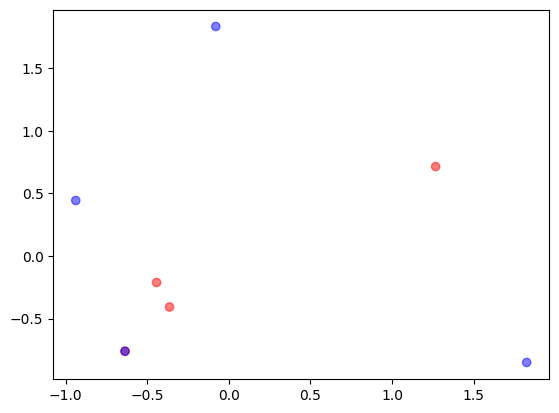

In [10]:
# doing PCA decomposition and plotting

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
embedded_texts = np.array(embedded_texts)
pca = PCA(n_components=2)
pca.fit(embedded_texts)
pca_transformed = pca.transform(embedded_texts)
xs = pca_transformed[:,0]
ys = pca_transformed[:,1]
print(pca_transformed.shape)
plt.scatter(xs, ys, alpha=0.5, color=['red' for _ in range(4)] + ['blue' for _ in range(4)])


# Now doing the same thing for all the speeches of representatives 

In [11]:
REPR_SPEECHD_DIR = os.path.join(DATA_DIR, 'data_repr')
LOWER_HOUSE_REPR_SPEECH_DIR = os.path.join(REPR_SPEECHD_DIR, 'lower')
UPPER_HOUSE_REPR_SPEECH_DIR = os.path.join(REPR_SPEECHD_DIR, 'upper')


In [12]:
topic = "安全保障"
parties_array = []
embeddings = []
repr_names = []
topic_dir = os.path.join(UPPER_HOUSE_REPR_SPEECH_DIR, topic)
for party_name in os.listdir(topic_dir):
    print("Embedding speeches of", topic, party_name)
   
    party_dir = os.path.join(topic_dir, party_name)
    for repr_file_name in os.listdir(party_dir):
        print("Working in", topic, party_name, repr_file_name)
        repr_file_path = os.path.join(party_dir, repr_file_name)
        repr_json = read_json(repr_file_path)
        print(repr_json)
        
        if repr_json[0]['numberOfRecords'] == 0:
            continue
        speech_concat = ''
        for speech_record in repr_json[0]['speechRecord']:
            speech_concat += speech_record['speech']
        speech_embd = sentence_transformer.encode(speech_concat)
        embeddings.append(speech_embd)
        repr_names.append(re.sub('.json', '', repr_file_name))    
        parties_array.append(party_name)
embeddings_np = np.array(embeddings)
np.savez(os.path.join(UPPER_HOUSE_REPR_SPEECH_DIR, topic, 'embeddings.npz'), embeddings_np)
with open(os.path.join(UPPER_HOUSE_REPR_SPEECH_DIR, topic, 'repr_names.pkl'), 'wb') as f:
    pickle.dump(repr_names, f)
with open(os.path.join(UPPER_HOUSE_REPR_SPEECH_DIR, topic, 'parties_array.pkl'), 'wb') as f:
    pickle.dump(parties_array, f)
   


Embedding speeches of 安全保障 無所属
Working in 安全保障 無所属 ながえ孝子[永江孝子].json
[{'numberOfRecords': 0, 'numberOfReturn': 0, 'startRecord': 1, 'nextRecordPosition': None}]
Working in 安全保障 無所属 長浜博行.json
[{'numberOfRecords': 12, 'numberOfReturn': 12, 'startRecord': 1, 'nextRecordPosition': None, 'speechRecord': [{'speechID': '120015254X00220191008_002', 'issueID': '120015254X00220191008', 'imageKind': '会議録', 'searchObject': 2, 'session': 200, 'nameOfHouse': '参議院', 'nameOfMeeting': '本会議', 'issue': '第2号', 'date': '2019-10-08', 'closing': None, 'speechOrder': 2, 'speaker': '長浜博行', 'speakerYomi': 'ながはまひろゆき', 'speakerGroup': '立憲・国民．新緑風会・社民', 'speakerPosition': None, 'speakerRole': None, 'speech': '○長浜博行君\u3000立憲・国民．新緑風会・社民の長浜博行です。\r\n\u3000会派を代表して、総理の所信について質問をいたします。\r\n\u3000今年も夏から秋にかけて度重なる台風や集中豪雨等により各地に大きな被害が生じました。質問に先立ち、お亡くなりになられた方々に哀悼の意を表しますとともに、被害に遭われた皆様に心からお見舞いを申し上げます。被災地が一日も早く復興するように、私どもとしても全力で支援に取り組んでまいります。\r\n\u3000まずは、千葉県を中心として広範囲に被害が生じた台風第十五号について、千葉県民の一人として政府の初動対応の遅れについてお伺いをいたします。\r\n\u3000台風第十

number of parties {'共産', 'れ新', '民主', '沖縄', '立憲', '公明', '女子', '無所属', '自民', '維新'}
(1, 768)
(198, 768)
(198,)


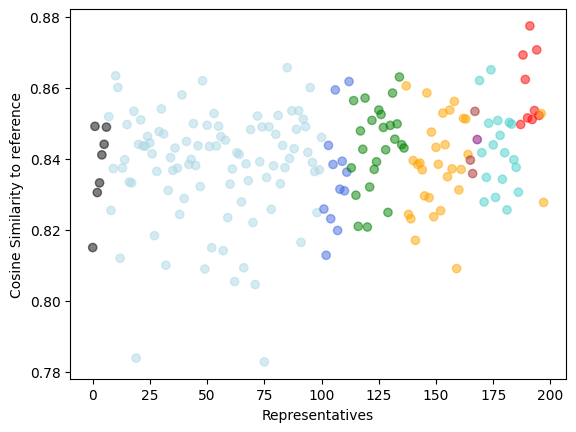

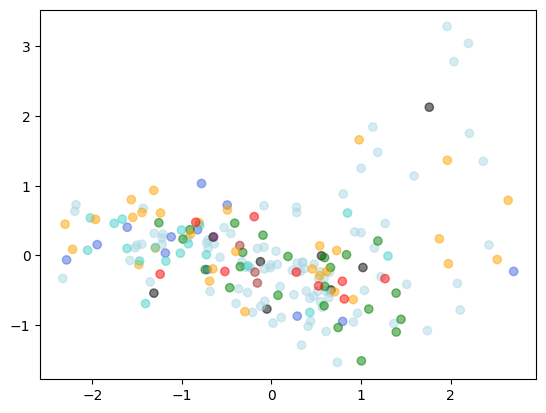

In [38]:
embeddings_np = np.load(os.path.join(UPPER_HOUSE_REPR_SPEECH_DIR, topic, 'embeddings.npz'))['arr_0']
party2color = {
    '自民': 'lightblue',
    '公明': 'green',
    '立憲': 'orange',
    '民主': 'royalblue',
    '共産': 'red',
    '維新': 'mediumturquoise',
    'れ新':'brown',
    '女子':'purple',
    '無所属': 'black',
    '沖縄': 'orange'
    
}
print('number of parties', set(parties_array))
# measuring the cosine similarity to the reference sentence to see whether we can measure political stance
ref_sentence = '憲法に自衛隊を明記すべきである。防衛費を増やすべきである。'
ref_embd = sentence_transformer.encode([ref_sentence])
print(ref_embd.shape)
print(embeddings_np.shape)
def cosine_similarity(a, b):
    dots = np.dot(a, b.T)
    norms = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1)
    return dots/norms
cosine_similarities = cosine_similarity(ref_embd, embeddings_np)
cosine_similarities = cosine_similarities.reshape(-1)
print(cosine_similarities.shape)
x_axis = np.arange(len(cosine_similarities))
plt.scatter(x_axis,cosine_similarities , alpha=0.5, color=[party2color[party] for party in parties_array])
plt.xlabel('Representatives')
plt.ylabel('Cosine Similarity to reference')
plt.show()
plt.cla()
plt.clf()


#PCA decomposition to see if we can see any clustering1
pca = PCA(n_components=2)
pca.fit(embeddings_np)
embeddings_transformed = pca.transform(embeddings_np)
xs = embeddings_transformed[:,0]
ys = embeddings_transformed[:,1]
plt.scatter(xs, ys, alpha=0.5, color=[party2color[party] for party in parties_array])


# Using pretrained large GPT model to estimate the stance by generating additional sentences

In [3]:
from transformers import pipeline
unmasker = pipeline('fill-mask', model='cl-tohoku/bert-large-japanese')

Some weights of the model checkpoint at cl-tohoku/bert-large-japanese were not used when initializing BertForMaskedLM: ['cls.seq_relationship.weight', 'cls.seq_relationship.bias']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


[{'score': 0.6657539010047913,
  'token': 12292,
  'token_str': '反対',
  'sequence': '本 予算 案 は 、 専守 防衛 を 投げ捨て た 敵 基地 攻撃 能力 の 保有 、 五 年間 で 四十 三 兆 円 も の 大 軍拡 を 進める もの です 。 防衛 関連 予算 、 軍事 費 は プラス 八 九 ・ 四 % 、 四 ・ 八 兆 円 も 増額 し 、 その 一方 で 、 社会 保障 は 自然 増 に よる 必要 額 を 一千 五百 億 円 も 抑え込む 、 中 小 企業 対策 も 農業 支援 で ある 食料 安定 供給 も マイナス と する など 、 国民 を 犠牲 に し 、 大 軍拡 に 突き進む 戦後 最悪 の 予算 で あり 、 断固 と し て 反対 する もの です 。 防衛 費 の 増額 に 反対 し ます 。'},
 {'score': 0.21514618396759033,
  'token': 17502,
  'token_str': '賛成',
  'sequence': '本 予算 案 は 、 専守 防衛 を 投げ捨て た 敵 基地 攻撃 能力 の 保有 、 五 年間 で 四十 三 兆 円 も の 大 軍拡 を 進める もの です 。 防衛 関連 予算 、 軍事 費 は プラス 八 九 ・ 四 % 、 四 ・ 八 兆 円 も 増額 し 、 その 一方 で 、 社会 保障 は 自然 増 に よる 必要 額 を 一千 五百 億 円 も 抑え込む 、 中 小 企業 対策 も 農業 支援 で ある 食料 安定 供給 も マイナス と する など 、 国民 を 犠牲 に し 、 大 軍拡 に 突き進む 戦後 最悪 の 予算 で あり 、 断固 と し て 反対 する もの です 。 防衛 費 の 増額 に 賛成 し ます 。'},
 {'score': 0.02113805152475834,
  'token': 17443,
  'token_str': '同意',
  'sequence': '本 予算 案 は 、 専守 防衛 を 投げ捨て た 敵 基地 攻撃 能力 の 保有 、 五 年間 で 四十 三 兆 円 も の 大 軍拡 を 進める もの です 

In [7]:
opinion_mask = '防衛費の増額に[MASK]します。'
against_increasing_defence_budget = '本予算案は、専守防衛を投げ捨てた敵基地攻撃能力の保有、五年間で四十三兆円もの大軍拡を進めるものです。防衛関連予算、軍事費はプラス八九・四％、四・八兆円も増額し、その一方で、社会保障は自然増による必要額を一千五百億円も抑え込む、中小企業対策も農業支援である食料安定供給もマイナスとするなど、国民を犠牲にし、大軍拡に突き進む戦後最悪の予算であり、断固として反対するものです。'
for_increasing_defence_budget = '○内閣総理大臣（岸田文雄君）　舩後靖彦議員の御質問にお答えをいたします。\r\n　まず、防衛予算等にお尋ねがありました。\r\n　新たに策定された三文書に基づく取組は、憲法及び国際法の範囲内で行うものであり、専守防衛の考え方も変更するものではありません。\r\n　防衛力の抜本的強化は、国民の命や暮らしを守り抜くために必要です。その検討に際しては、戦後最も厳しく複雑な安全保障環境に対峙していく中で、国民の命を守り抜けるか、極めて現実的なシミュレーションを行いました。一年以上にわたって議論を積み重ねており、その過程において、必要となる防衛力の内容を積み上げ、防衛力の規模を導き出した上で令和五年度予算に所要額を計上しており、必要な予算であると考えております。'
against_prediction = unmasker(against_increasing_defence_budget+opinion_mask)
for_prediction = unmasker(for_increasing_defence_budget+opinion_mask)
print('against')
for prediction in against_prediction:
	print(prediction)
print("-------------------------------------------------------------------------")
print("for")
for prediction in for_prediction:
	print(prediction)

against


TypeError: sequence item 0: expected str instance, dict found

In [1]:
# using pretrained Japanese GPT model to see if we can deduce stance of politicians
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("rinna/japanese-gpt-neox-3.6b", use_fast=False)
model = AutoModelForCausalLM.from_pretrained("rinna/japanese-gpt-neox-3.6b")

if torch.cuda.is_available():
    model = model.to("cuda")

text = "西田幾多郎は、"
token_ids = tokenizer.encode(text, add_special_tokens=False, return_tensors="pt")

with torch.no_grad():
    output_ids = model.generate(
        token_ids.to(model.device),
        max_new_tokens=100,
        min_new_tokens=100,
        do_sample=True,
        temperature=0.8,
        pad_token_id=tokenizer.pad_token_id,
        bos_token_id=tokenizer.bos_token_id,
        eos_token_id=tokenizer.eos_token_id
    )
output = tokenizer.decode(output_ids.tolist()[0])
print(output)

/root/projects/kokkai_analysis/data_prepping/kokkai_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


: 

: 